In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

# Task 1 — Persiapan Data dan Baseline Model


In [2]:
df = pd.read_csv('telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop('customerID', axis= 1, inplace= True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset='TotalCharges', inplace=True)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == "Yes" else 0)

In [4]:
df_categorical = df.select_dtypes('object')
df_numerical = df.select_dtypes('number')

print(f"Kolom categorical: {df_categorical.columns}")
print(f"Kolom numerical: {df_numerical.columns}")

Kolom categorical: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Kolom numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


In [6]:
train =  df_numerical.drop('Churn', axis = 1)[['tenure','MonthlyCharges','TotalCharges']]
test = df_numerical['Churn']

X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.2, random_state=42)

In [7]:
model = LogisticRegression(max_iter=1000)
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

In [8]:

cross_val = cross_val_score(model, X_train, y_train, cv = kfold, scoring='accuracy')
print("Standard Deviasion Accuracy:", np.std(cross_val))
print("Mean Accuracy:", np.mean(cross_val))

Standard Deviasion Accuracy: 0.012625977532134926
Mean Accuracy: 0.7864888888888888


# Task 2 — Feature Scaling dan Dampaknya


Text(0.5, 0, 'TotalCharges')

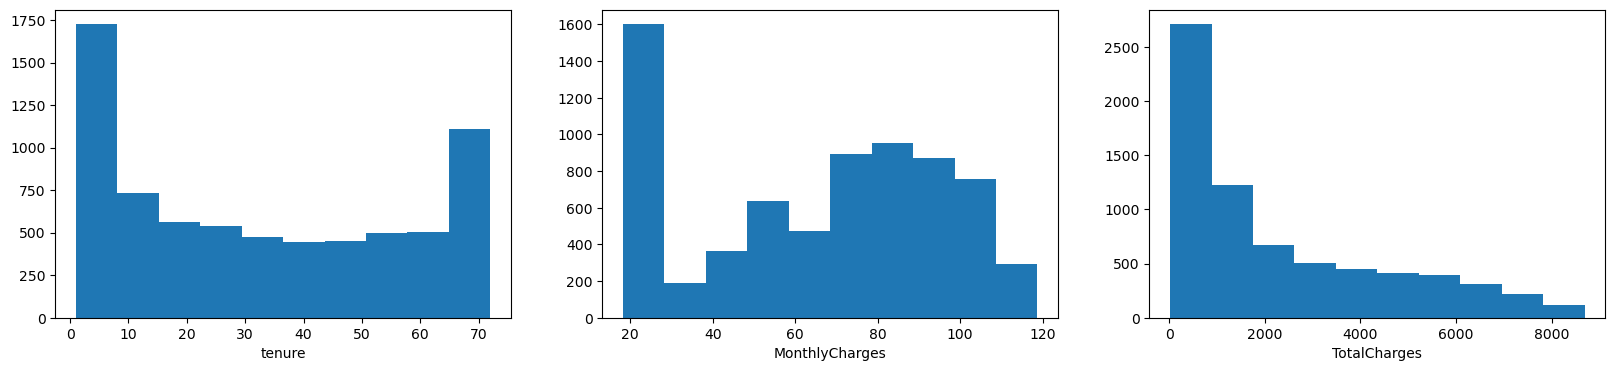

In [10]:
fig, ax = plt.subplots(1,3, figsize=(20,4))
ax[0].hist(df['tenure'])
ax[0].set_xlabel('tenure')

ax[1].hist(df['MonthlyCharges'])
ax[1].set_xlabel('MonthlyCharges')

ax[2].hist(df['TotalCharges'])
ax[2].set_xlabel('TotalCharges')

Dikarenakan distribusi data untuk fitur tenure, MonthlyCharges, dan TotalCharges tidak normal dan mengandung outliers pada fitur TotalCharges, maka scaling yang akan digunakan adalah RobustScaler. Dikarenakan kita tidak mau menghilangkan makna data yang ada di data outlier pada fitur TotalCharges

In [ ]:
scaler = RobustScaler()
X_train_scaled_robust = scaler.fit_transform(X_train)
X_test_scaled_robust = scaler.transform(X_test)

scaler = StandardScaler()
X_train_scaled_standart = scaler.fit_transform(X_train)
X_test_scaled_standart = scaler.transform(X_test)

scaler = MinMaxScaler()
X_train_scaled_minmax = scaler.fit_transform(X_train)
X_test_scaled_minmax = scaler.transform(X_test)

In [12]:
model = LogisticRegression()
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

In [13]:
score = cross_val_score(model,X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.01323698522239024
Mean Accuracy: 0.7859555555555555


|               | Task 1 | Task 2 |
|---------------|--------|--------|
| Std Accuracy  |   0.0126     |   0.0132     |
| Mean Accuracy |    0.786    |     0.785   |

Pada task 1 rata rata akurasi untuk 5 fold yang didapatkan adalah 0.786. Pada task 2, data yang usudah di scale dan diperlakukan sama seperti pada task 1, menghasilkan akurasi 0.785. Hal ini menunjukkan bahwa tidak ada perubahan yanng signifikan untuk data yang sebelum dan sesudah di scaling.

# Task 3 — Encoding Fitur Kategorikal


In [14]:
print(f"Ordinal: {['Contract']}")
print(f"Nominal: {['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'PaperlessBilling', 'PaymentMethod']}")

Ordinal: ['Contract']
Nominal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'PaperlessBilling', 'PaymentMethod']


In [15]:
ord_encoder = OrdinalEncoder()
df['Contract'] = ord_encoder.fit_transform(df[['Contract']])

In [21]:
df_dummy = pd.get_dummies(df_categorical[['InternetService', 'PaymentMethod']], drop_first= True)
df_dummy.columns.to_list()

['InternetService_Fiber optic',
 'InternetService_No',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [22]:
df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerical),
    columns=df_numerical.columns,
    index=df_numerical.index
)
df_numerical_scaled

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn
0,0.0,-0.608696,0.0,-0.746200,-0.403038,0.0
1,0.0,0.108696,1.0,-0.246891,0.145000,0.0
2,0.0,-0.586957,0.0,-0.304007,-0.379963,1.0
3,0.0,0.347826,1.0,-0.516813,0.130633,0.0
4,0.0,-0.586957,0.0,0.006449,-0.367144,1.0
...,...,...,...,...,...,...
7038,0.0,-0.108696,1.0,0.266237,0.174764,0.0
7039,0.0,0.934783,1.0,0.605251,1.758008,0.0
7040,0.0,-0.391304,0.0,-0.750806,-0.309737,0.0
7041,1.0,-0.543478,0.0,0.074620,-0.321480,1.0


In [23]:
df_encoded = pd.concat([df_numerical_scaled,df_dummy, df_categorical[['gender','Partner', 'Dependents','PhoneService']]],axis=1)
df_encoded['gender'] = df_encoded['gender'].map(lambda x: 1 if x =="Male" else 0)
df_encoded['Partner']= df_encoded['Partner'].map(lambda x: 1 if x =="Yes" else 0)
df_encoded['Dependents'] = df_encoded['Dependents'].map(lambda x: 1 if x =="Yes" else 0)
df_encoded['PhoneService'] = df_encoded['PhoneService'].map(lambda x: 1 if x =="Yes" else 0)

In [24]:
X_final = df_encoded.drop('Churn', axis = 1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [25]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

In [26]:
score = cross_val_score(model, X_train, y_train, cv = kfold, scoring='accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.011513084343958877
Mean Accuracy: 0.8001777777777779


# Task 4 — Feature Selection Berbasis Korelasi


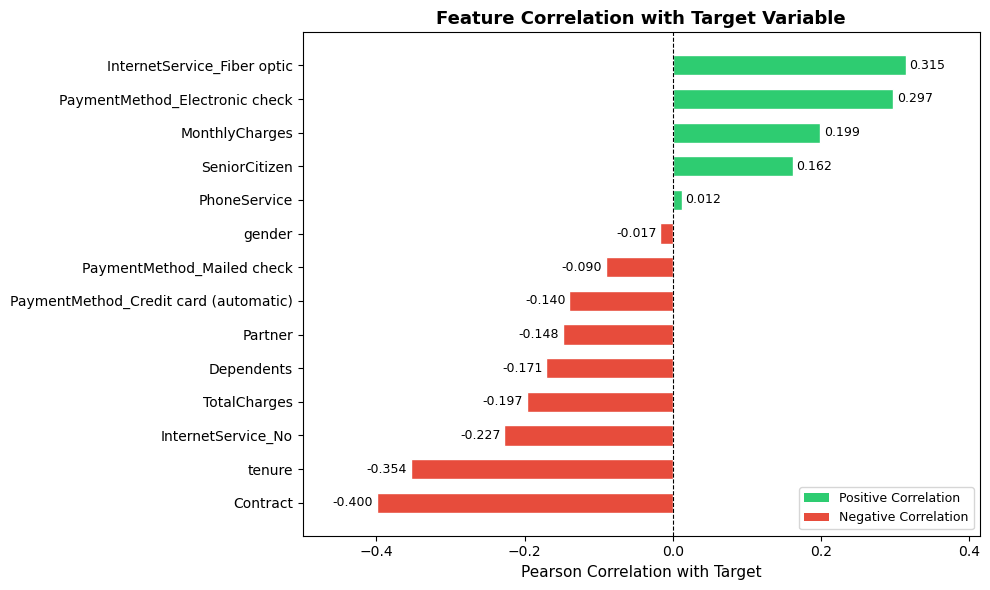

In [27]:
corr_series = (
    pd.concat([X_final, y_train], axis=1)
    .corr()[y_train.name]          
    .drop(y_train.name)            
    .sort_values(ascending=True)   
)

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_series]

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_series) * 0.35)))
bars = ax.barh(corr_series.index, corr_series.values, color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, corr_series.values):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Pearson Correlation with Target", fontsize=11)
ax.set_title("Feature Correlation with Target Variable", fontsize=13, fontweight="bold")
ax.set_xlim(corr_series.min() - 0.1, corr_series.max() + 0.1)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Positive Correlation"),
    Patch(facecolor="#e74c3c", label="Negative Correlation"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


In [28]:
X = X_final.drop(['PhoneService','gender','PaymentMethod_Mailed check'],axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [29]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

In [30]:
score = cross_val_score(model, X_train, y_train, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.014171018939292212
Mean Accuracy: 0.7980444444444444


| Eksperimen | Mean Accuracy | Std Accuracy |
|---|---|---|
| Baseline | 0.7865 | 0.0126 | 
| Setelah Scaling | 0.7860 | 0.0132 |
| Setelah Scaling + Encoding | **0.8002** | **0.0115** |
| Setelah Feature Selection | 0.7980 | 0.0142 |

- **Scaling saja** tidak memberikan peningkatan — akurasi justru sedikit turun (~0.05%).
- **Scaling + Encoding** memberikan hasil terbaik: akurasi naik sekitar 1.37% dan standar deviasi
  paling rendah, artinya model paling **stabil**.
- **Feature Selection** tetap lebih baik dari Baseline (+1.15%), namun sedikit di bawah
  Scaling + Encoding dengan stabilitas yang lebih rendah (std tertinggi: 0.0142).
